In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from odc.geo.xr import ODCExtensionDa
from odc.geo import GeoboxTiles

In [ ]:
ix = 0; iy = 0

# Load data
parquet_tile = pd.read_parquet(f"/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/assembled/1km.parquet/ix={ix}/iy={iy}/data.parquet")
land_mask = xr.open_zarr("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/misc/processed/stage_2/osm/land_mask.zarr", consolidated = False)

# Create tiles
tile_size = (2048, 2048)
tile = GeoboxTiles(land_mask.odc.geobox, tile_size)[ix,iy]

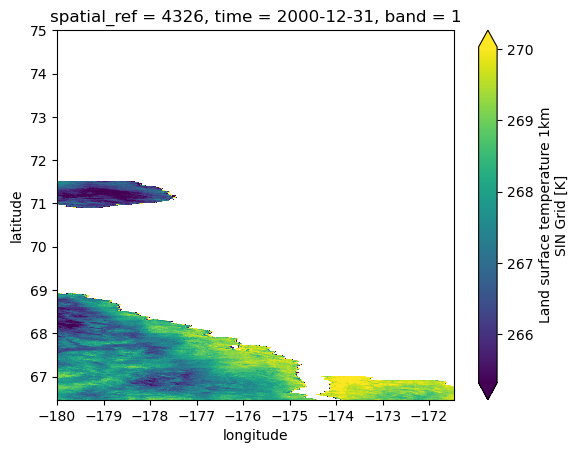

In [10]:
modis = xr.open_zarr("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/glass/LST/MODIS/Daily/1KM/processed/stage_2/modis_timeseries_reprojected.zarr", consolidated=False)
modis = modis.odc.assign_crs(4326)
modis.odc.crop(tile.extent).isel(time=0, band=0)["median"].compute().plot.imshow(robust=True)

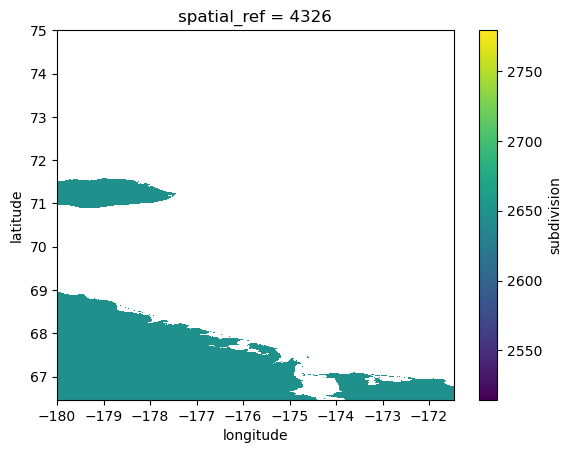

In [14]:
subdivisions = xr.open_zarr("/scicore/home/meiera/schulz0022/projects/growth-and-temperature/data_nobackup/misc/processed/stage_2/gadm/countries_grid.zarr", consolidated=False)
subdivisions = subdivisions.odc.assign_crs(4326)
subdivisions.odc.crop(tile.extent)["subdivision"].compute().plot.imshow(robust=True)

In [5]:
h, w = tile.shape
local_pixel_ids = np.arange(h * w, dtype="uint32").reshape((h, w))
pixel_id_matrix = (np.uint64(ix) << 48) | (np.uint64(iy) << 32) | local_pixel_ids.astype(np.uint64)

conversion_matrix = np.stack([pixel_id_matrix] + list(np.meshgrid(tile.coords["longitude"].values, tile.coords["latitude"].values))).reshape(3, -1)

conversion_df = pd.DataFrame({x: conversion_matrix[i,:] for i, x in enumerate(["pixel_id", "longitude", "latitude"])})

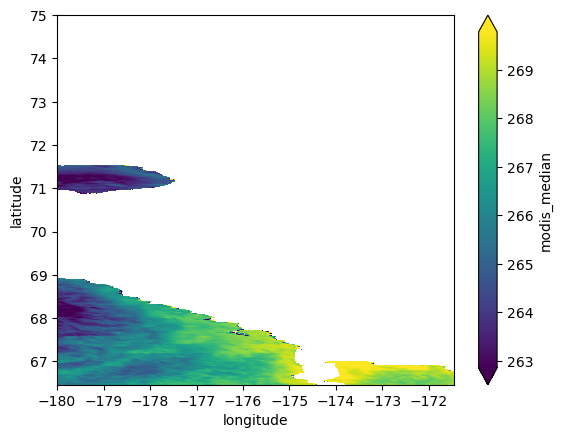

In [7]:
test = xr.Dataset.from_dataframe(pd.merge(parquet_tile.query("year==2013"), conversion_df, how="outer", on="pixel_id").set_index(["latitude", "longitude"])[["modis_median"]])

test.modis_median.plot.imshow(robust=True)